In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# XGBoost
import xgboost as xgb

# Настройки
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Загрузка данных

In [4]:
# Загрузка данных по предоставленной ссылке
excel_url = 'https://lms.skillfactory.ru/asset-v1:SkillFactory+MIFIML-2sem+2025+type@asset+block@%D0%94%D0%B0%D0%BD%D0%BD%D1%8B%D0%B5_%D0%B4%D0%BB%D1%8F_%D0%BA%D1%83%D1%80%D1%81%D0%BE%D0%B2%D0%BE%D0%B8__%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B5_%D0%9C%D0%9E.xlsx'
df = pd.read_excel(excel_url)

# Удаление технического столбца 'Unnamed: 0'
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print(f"Размерность данных: {df.shape}")
display(df.head())

Размерность данных: (1001, 213)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


## 3. Разведочный анализ данных (EDA)

На этом этапе мы изучим структуру данных, наличие пропусков, распределение целевых переменных и их корреляцию.

In [5]:
# Базовая статистика и проверка на пропуски
print("Общая информация о данных:")
df.info()

print("\nПропуски в данных:")
missing_cols = df.isnull().sum()[df.isnull().sum() > 0]
print(missing_cols) # Выводим только столбцы с пропусками

# --- Проверка распределения пропусков по строкам ---
rows_with_na = df[df.isnull().any(axis=1)]
print(f"\nКоличество строк, содержащих хотя бы один пропуск: {len(rows_with_na)}")
print("Индексы этих строк:", rows_with_na.index.tolist())
display(rows_with_na[missing_cols.index]) # Покажем эти строки для проблемных столбцов

print("\nОписательная статистика целевых переменных:")
targets = ['IC50, mM', 'CC50, mM', 'SI']
display(df[targets].describe())

print("\nПоиск выбросов в целевых переменных (метод IQR):")
for col in targets:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {outliers.shape[0]} выбросов ({outliers.shape[0] / len(df) * 100:.2f}% данных)")

# --- Ответ на вопрос о природе признаков ---
print("\n--- Анализ независимых признаков (дескрипторов) ---")
print("Дескрипторы рассчитываются аналитически из графа молекулы. Физических ошибок датчиков здесь нет.")
print("Однако возможны 'выбросы' из-за редких химических структур или очень крупных молекул.")

features = df.drop(columns=targets)

# Проверка на константные признаки (нулевая дисперсия)
constant_features = [col for col in features.columns if features[col].nunique() <= 1]
print(f"\nНайдено константных признаков (одно значение для всех молекул): {len(constant_features)}")
if len(constant_features) > 0:
    print(f"Примеры: {constant_features[:5]}")

# Оценка количества признаков с выбросами (по IQR)
features_with_outliers = 0
for col in features.select_dtypes(include=np.number).columns:
    Q1 = features[col].quantile(0.25)
    Q3 = features[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0: # Игнорируем сильно разреженные или бинарные признаки
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers_count = ((features[col] < lower) | (features[col] > upper)).sum()
        if outliers_count > 0:
            features_with_outliers += 1

print(f"Признаков, имеющих математические выбросы (по методу IQR): {features_with_outliers} из {len(features.columns)}")
print("В химическом ML такие 'выбросы' чаще всего оставляют, так как они несут реальную информацию о строении молекулы.")


Общая информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB

Пропуски в данных:
MaxPartialCharge       3
MinPartialCharge       3
MaxAbsPartialCharge    3
MinAbsPartialCharge    3
BCUT2D_MWHI            3
BCUT2D_MWLOW           3
BCUT2D_CHGHI           3
BCUT2D_CHGLO           3
BCUT2D_LOGPHI          3
BCUT2D_LOGPLOW         3
BCUT2D_MRHI            3
BCUT2D_MRLOW           3
dtype: int64

Количество строк, содержащих хотя бы один пропуск: 3
Индексы этих строк: [78, 79, 80]


,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW
78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Описательная статистика целевых переменных:


,"IC50, mM","CC50, mM",SI
count,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823
std,402.169734,642.867508,684.482739
min,0.003517,0.700808,0.011489
25%,12.515396,99.999036,1.433333
50%,46.585183,411.039342,3.846154
75%,224.975928,894.089176,16.566667
max,4128.529377,4538.976189,15620.600000



Поиск выбросов в целевых переменных (метод IQR):
IC50, mM: 147 выбросов (14.69% данных)
CC50, mM: 39 выбросов (3.90% данных)
SI: 125 выбросов (12.49% данных)

--- Анализ независимых признаков (дескрипторов) ---
Дескрипторы рассчитываются аналитически из графа молекулы. Физических ошибок датчиков здесь нет.
Однако возможны 'выбросы' из-за редких химических структур или очень крупных молекул.

Найдено константных признаков (одно значение для всех молекул): 18
Примеры: ['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH']
Признаков, имеющих математические выбросы (по методу IQR): 114 из 210
В химическом ML такие 'выбросы' чаще всего оставляют, так как они несут реальную информацию о строении молекулы.


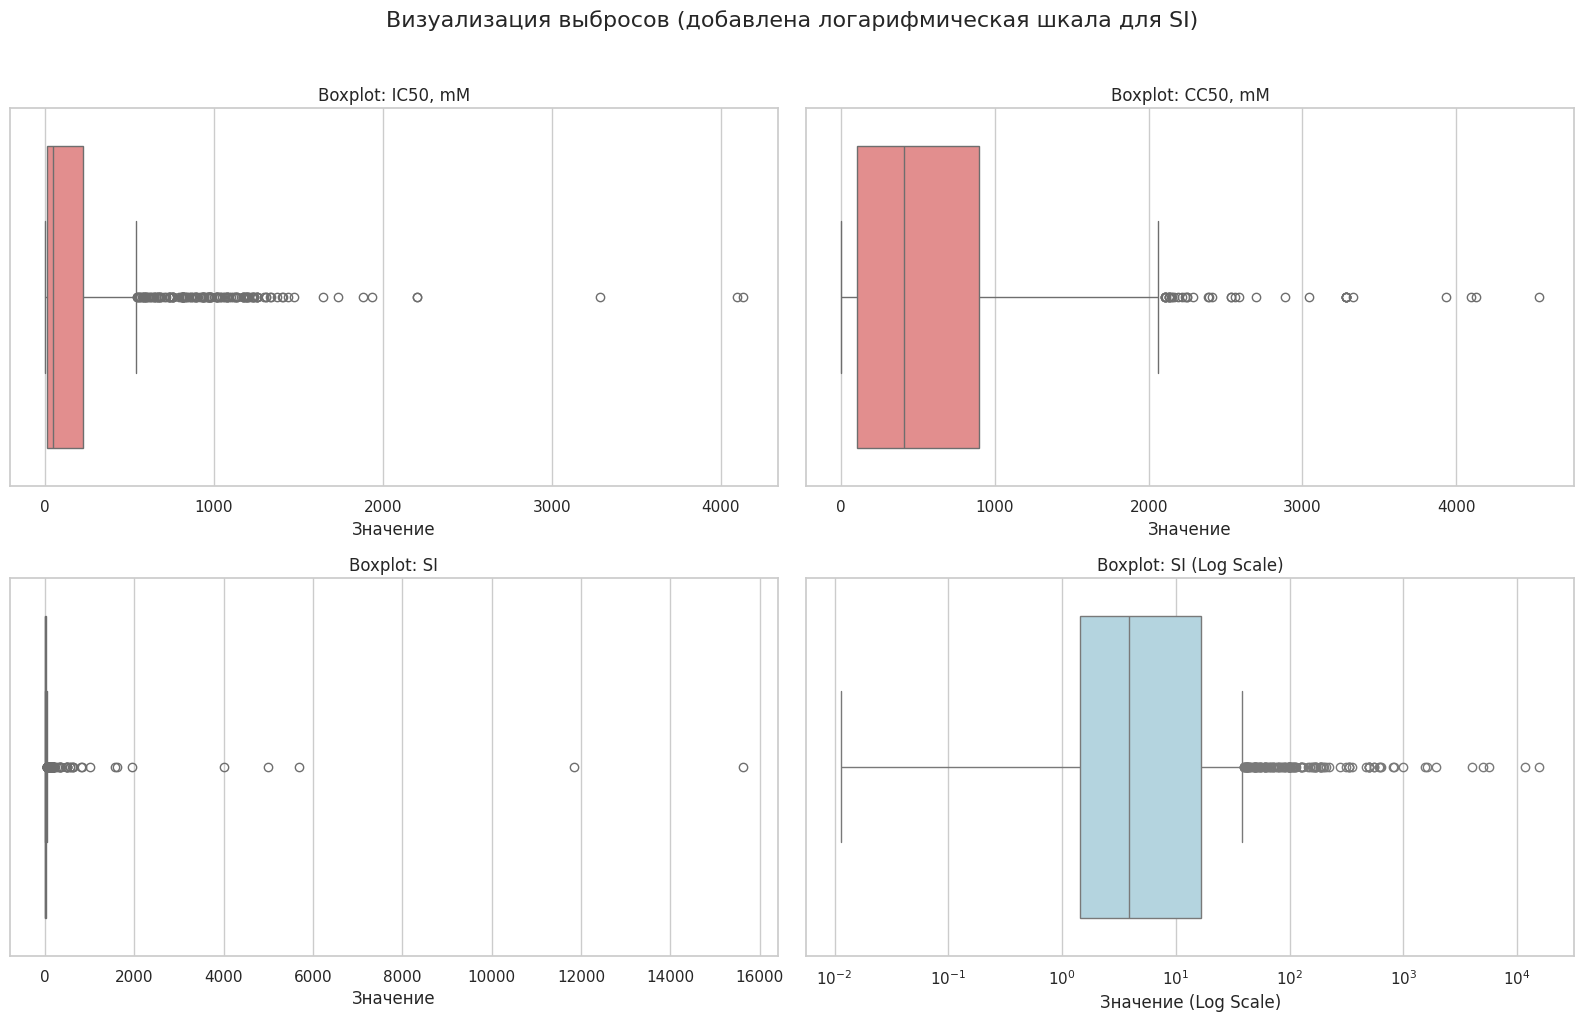

In [6]:
# Визуализация выбросов в целевых переменных с помощью графиков "ящик с усами" (Boxplot)
# Сделаем сетку 2х2 для лучшей читаемости графиков
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()

# Первые 3 графика - обычная (линейная) шкала
for i, target in enumerate(targets):
    sns.boxplot(x=df[target], ax=axes_flat[i], color='lightcoral')
    axes_flat[i].set_title(f'Boxplot: {target}')
    axes_flat[i].set_xlabel('Значение')

# 4-й график - SI в логарифмической шкале для наглядности
sns.boxplot(x=df['SI'], ax=axes_flat[3], color='lightblue')
axes_flat[3].set_title('Boxplot: SI (Log Scale)')
axes_flat[3].set_xlabel('Значение (Log Scale)')
axes_flat[3].set_xscale('log')

plt.suptitle('Визуализация выбросов (добавлена логарифмическая шкала для SI)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### Описание набора данных

В нашем распоряжении находится датасет, содержащий информацию о 1000 уникальных химических соединениях. Данные собраны для прогнозирования эффективности потенциальных лекарственных препаратов против вируса гриппа.

**Целевые переменные (то, что мы предсказываем):**
1. **`IC50, mM` (Полумаксимальная ингибирующая концентрация):** Показывает, какая концентрация вещества необходима для подавления активности вируса на 50%. *Чем ниже это значение, тем более эффективным является препарат.*
2. **`CC50, mM` (Полумаксимальная цитотоксическая концентрация):** Отражает уровень токсичности препарата для здоровых клеток организма. *Чем выше это значение, тем безопаснее лекарство.*
3. **`SI` (Индекс селективности):** Рассчитывается как отношение `CC50` к `IC50` (`SI = CC50 / IC50`). Это важнейший комплексный показатель, отражающий баланс между эффективностью и безопасностью. *Высокий показатель SI означает, что препарат хорошо справляется с вирусом, нанося минимальный вред организму пациента.*

**Признаки (независимые переменные, на которых учатся модели):**
Остальные более чем 200 столбцов представляют собой молекулярные дескрипторы — числовые характеристики химических структур:
* **Физико-химические свойства:** (например, `MaxAbsEStateIndex`, `BCUT2D`, молекулярная масса, заряды). Они описывают пространственное и энергетическое строение молекулы.
* **Количественные оценки:** показатели, оценивающие, насколько молекула близка по свойствам к уже известным лекарственным средствам (например, индекс `qed`).
* **Функциональные группы:** столбцы с префиксом `fr_` (например, `fr_sulfide`, `fr_urea`, `fr_thiazole`). Они указывают на наличие и количество определенных химических фрагментов (сульфидов, мочевины и т.д.) в структуре молекулы.

Именно на основе этих структурных характеристик (дескрипторов) наши модели будут пытаться предсказать медицинскую эффективность (IC50, CC50 и SI) каждого соединения.

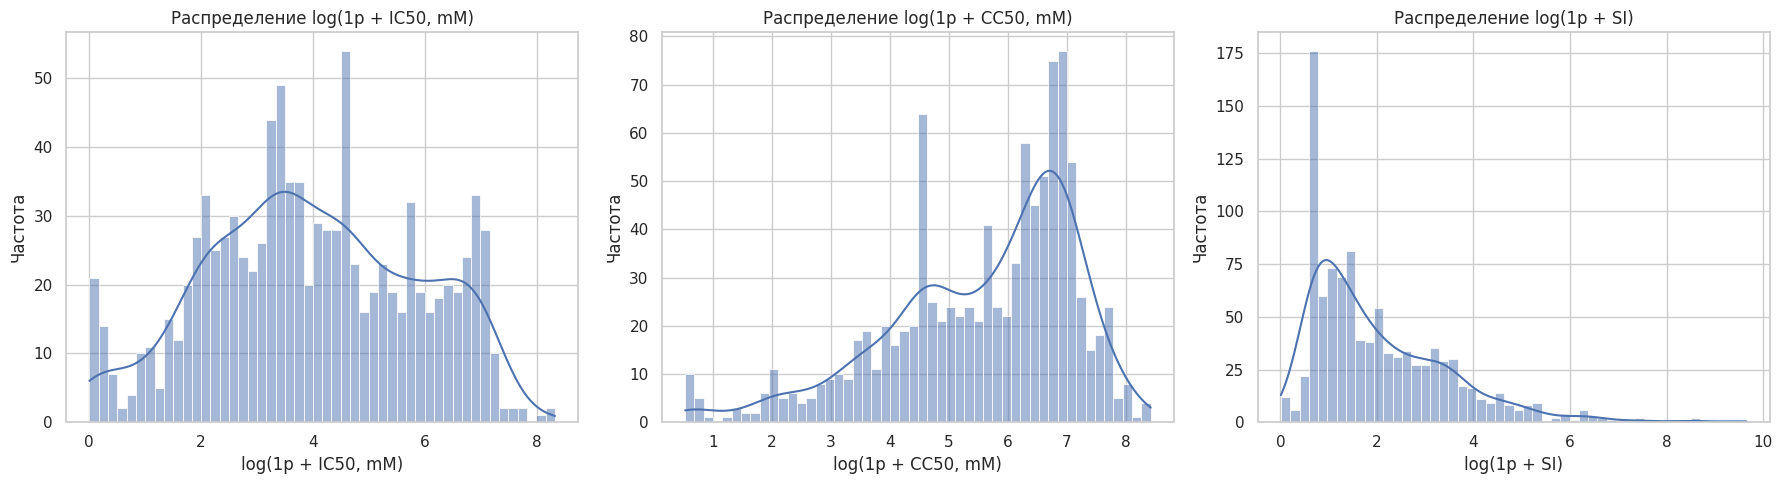

In [7]:
# Логарифмирование целевых переменных для нормализации распределения
# Так как значения могут иметь большой разброс и сильную асимметрию
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(targets):
    # Добавляем небольшую константу, чтобы избежать log(0), если есть нули
    sns.histplot(np.log1p(df[target]), kde=True, ax=axes[i], bins=50)
    axes[i].set_title(f'Распределение log(1p + {target})')
    axes[i].set_xlabel(f'log(1p + {target})')
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

###Считать корреляцию бессмысленно.

Из-за распределения целевых признаков и наличия сильных выбросов стандартная корреляция Пирсона будет работать некорректно. Кроме того, зависимость между SI, CC50 и IC50 не является линейной, так как SI математически является их частным (SI = CC50 / IC50).

1. **Да и считать попарную корреляцию между итоговым частным (SI) и его отдельными компонентами (CC50 или IC50) в данном случае математически бессмысленно.**

2. **Необходимость машинного обучения:**
Для прогнозирования эффективности (SI) нам нужны многомерные алгоритмы машинного обучения, которые способны оценивать влияние сотен молекулярных дескрипторов одновременно, а не попарно.

### Выводы по EDA:
1. **Данные:** Загружено более 1000 записей и более 200 признаков. Пропуски  минимальны.
2. **Распределение таргетов:** Целевые переменные (IC50, CC50, SI) имеют сильно скошенное распределение (длинный хвост вправо). Логарифмирование (log1p) делает распределения более нормальными, что полезно для линейных моделей. Однако деревья решений менее чувствительны к монотонным преобразованиям.
3. **Корреляции:** Ожидается, что SI будет иметь зависимость от IC50 и CC50, так как вычисляется на их основе, что тривеально.

## 4. Подготовка данных

Размерность датасета после удаления строк с пропусками: (998, 213)
Удалено константных признаков: 18
Размерность матрицы признаков X после очистки и масштабирования: (998, 192)

--- PCA: Проекция химического пространства ---


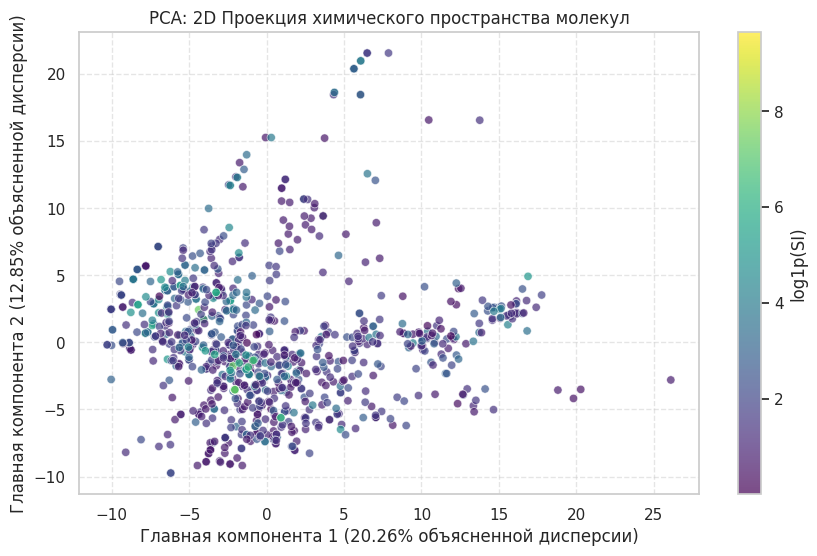

In [8]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

# Удаляем строки с пропусками, так как их всего 3 и они сконцентрированы в одних и тех же наблюдениях
df = df.dropna()
print(f"Размерность датасета после удаления строк с пропусками: {df.shape}")

# Исключаем целевые переменные из признакового пространства
X = df.drop(columns=targets)

# Находим и удаляем константные признаки (с нулевой дисперсией)
constant_features = [col for col in X.columns if X[col].nunique() <= 1]
X = X.drop(columns=constant_features)
print(f"Удалено константных признаков: {len(constant_features)}")

# Масштабирование признаков (важно для линейных моделей и PCA)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print(f"Размерность матрицы признаков X после очистки и масштабирования: {X_scaled.shape}")

# --- Дополнительный EDA: Визуализация химического пространства (PCA) ---
print("\n--- PCA: Проекция химического пространства ---")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
# Раскрашиваем точки в зависимости от логарифма целевой переменной SI
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=np.log1p(df['SI']), cmap='viridis', alpha=0.7, edgecolors='w', linewidth=0.5)
plt.colorbar(scatter, label='log1p(SI)')
plt.title('PCA: 2D Проекция химического пространства молекул')
plt.xlabel(f'Главная компонента 1 ({pca.explained_variance_ratio_[0]:.2%} объясненной дисперсии)')
plt.ylabel(f'Главная компонента 2 ({pca.explained_variance_ratio_[1]:.2%} объясненной дисперсии)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Судя по всему главные компоненты очень плохо обясняют дисперсию. Светлых желтых точек особо не видно.

Из-за того, что я не знаю насколько важны редкие значения признаков я создам 3 списка наблюдений с отсечением по уровню кореляции Пирсона на 0.85, 09, и 0.95. По каждому из них прогоним модель и поймём теряем ли мы выжную информацию.

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Вычисляем матрицу корреляций Пирсона (берем абсолютные значения)
corr_matrix = X_scaled.corr().abs()

# Оставляем только верхний треугольник матрицы,
# чтобы избежать дублирования пар (A-B и B-A) и диагонали
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Создаем списки признаков для удаления для разных порогов корреляции
thresholds = [0.85, 0.90, 0.95]
to_drop_lists = {}

for threshold in thresholds:
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    to_drop_lists[threshold] = to_drop
    print(f"Порог корреляции {threshold}: {len(to_drop)} признаков к удалению")

# Сохраняем в отдельные переменные для дальнейшего использования
to_drop_85 = to_drop_lists[0.85]
to_drop_90 = to_drop_lists[0.90]
to_drop_95 = to_drop_lists[0.95]

print("\nСписки успешно созданы: `to_drop_85`, `to_drop_90`, `to_drop_95`.")


Порог корреляции 0.85: 61 признаков к удалению
Порог корреляции 0.9: 47 признаков к удалению
Порог корреляции 0.95: 33 признаков к удалению

Списки успешно созданы: `to_drop_85`, `to_drop_90`, `to_drop_95`.


ТО же самое делаем по Спирмену

In [10]:
# Вычисляем матрицу корреляций Спирмена (для улавливания нелинейных монотонных связей)
corr_matrix_spearman = X_scaled.corr(method='spearman').abs()

# Оставляем только верхний треугольник
upper_tri_spearman = corr_matrix_spearman.where(np.triu(np.ones(corr_matrix_spearman.shape), k=1).astype(bool))

# Создаем списки признаков для удаления для разных порогов корреляции по Спирмену
thresholds = [0.85, 0.90, 0.95]
to_drop_spearman_lists = {}

for threshold in thresholds:
    to_drop = [column for column in upper_tri_spearman.columns if any(upper_tri_spearman[column] > threshold)]
    to_drop_spearman_lists[threshold] = to_drop
    print(f"Порог Спирмена {threshold}: {len(to_drop)} признаков к удалению")

# Сохраняем в отдельные переменные
to_drop_spearman_85 = to_drop_spearman_lists[0.85]
to_drop_spearman_90 = to_drop_spearman_lists[0.90]
to_drop_spearman_95 = to_drop_spearman_lists[0.95]

print("\nСписки успешно созданы: `to_drop_spearman_85`, `to_drop_spearman_90`, `to_drop_spearman_95`.")


Порог Спирмена 0.85: 60 признаков к удалению
Порог Спирмена 0.9: 43 признаков к удалению
Порог Спирмена 0.95: 33 признаков к удалению

Списки успешно созданы: `to_drop_spearman_85`, `to_drop_spearman_90`, `to_drop_spearman_95`.


In [11]:
# Сравнение списков удаляемых признаков (Пирсон vs Спирмен)
thresholds = [0.85, 0.90, 0.95]

for threshold in thresholds:
    pearson_set = set(to_drop_lists[threshold])
    spearman_set = set(to_drop_spearman_lists[threshold])

    intersection = pearson_set.intersection(spearman_set)
    only_pearson = pearson_set - spearman_set
    only_spearman = spearman_set - pearson_set

    print(f"--- Порог {threshold} ---")
    print(f"Удаляются по Пирсону: {len(pearson_set)}")
    print(f"Удаляются по Спирмену: {len(spearman_set)}")
    print(f"Пересечение (совпадают): {len(intersection)}")
    print(f"Удаляются ТОЛЬКО по Пирсону: {len(only_pearson)}")
    print(f"Удаляются ТОЛЬКО по Спирмену: {len(only_spearman)}\n")


--- Порог 0.85 ---
Удаляются по Пирсону: 61
Удаляются по Спирмену: 60
Пересечение (совпадают): 56
Удаляются ТОЛЬКО по Пирсону: 5
Удаляются ТОЛЬКО по Спирмену: 4

--- Порог 0.9 ---
Удаляются по Пирсону: 47
Удаляются по Спирмену: 43
Пересечение (совпадают): 40
Удаляются ТОЛЬКО по Пирсону: 7
Удаляются ТОЛЬКО по Спирмену: 3

--- Порог 0.95 ---
Удаляются по Пирсону: 33
Удаляются по Спирмену: 33
Пересечение (совпадают): 30
Удаляются ТОЛЬКО по Пирсону: 3
Удаляются ТОЛЬКО по Спирмену: 3



 Большинство сильно скоррелированных признаков имеют именно линейную зависимость (которую находят оба метода). Однако те несколько признаков, которые находит только Спирмен, имеют сильную нелинейную монотонную связь.Дополнительная фильтрация по Спирмену может уменьшит мультиколлинеарность и упростит задачу для моделей машинного обучения. А может мы потеряем информацию

In [12]:
# Создаем списки признаков, которые удаляются ТОЛЬКО по Спирмену
only_spearman_lists = {}

for threshold in thresholds:
    pearson_set = set(to_drop_lists[threshold])
    spearman_set = set(to_drop_spearman_lists[threshold])

    # Признаки, которые есть в spearman_set, но отсутствуют в pearson_set
    only_spearman = list(spearman_set - pearson_set)
    only_spearman_lists[threshold] = only_spearman

    print(f"Порог {threshold}: {len(only_spearman)} признаков (только по Спирмену)")
    if len(only_spearman) > 0:
        print(f"Признаки: {only_spearman}\n")

# Сохраняем в отдельные переменные
only_spearman_85 = only_spearman_lists[0.85]
only_spearman_90 = only_spearman_lists[0.90]
only_spearman_95 = only_spearman_lists[0.95]


Порог 0.85: 4 признаков (только по Спирмену)
Признаки: ['Ipc', 'SMR_VSA10', 'PEOE_VSA14', 'VSA_EState10']

Порог 0.9: 3 признаков (только по Спирмену)
Признаки: ['Ipc', 'NumAromaticRings', 'VSA_EState10']

Порог 0.95: 3 признаков (только по Спирмену)
Признаки: ['Ipc', 'FpDensityMorgan2', 'VSA_EState10']



Посчитаем сколько есть колонок, где есть редкие особенные значения, а общее тело значение одинаково.

In [13]:
# Поиск квазиконстантных признаков
# Если одно и то же значение встречается более чем в 95% случаев, признак считается редким
QUASI_CONSTANT_THRESHOLD = 0.95
quasi_constant_features = []

for col in X_scaled.columns:
    most_frequent_value_ratio = X_scaled[col].value_counts(normalize=True).values[0]
    if most_frequent_value_ratio > QUASI_CONSTANT_THRESHOLD:
        quasi_constant_features.append(col)

print(f"Порог отсечения: {QUASI_CONSTANT_THRESHOLD * 100}% одинаковых значений")
print(f"Всего признаков: {X_scaled.shape[1]}")
print(f"Количество квазиконстантных признаков к потенциальному удалению: {len(quasi_constant_features)}")

if len(quasi_constant_features) > 0:
    print(f"Примеры редких (квазиконстантных) признаков: {quasi_constant_features[:5]}")


Порог отсечения: 95.0% одинаковых значений
Всего признаков: 192
Количество квазиконстантных признаков к потенциальному удалению: 34
Примеры редких (квазиконстантных) признаков: ['SMR_VSA2', 'EState_VSA11', 'fr_ArN', 'fr_Ar_COO', 'fr_Ar_NH']


In [14]:
# Создаем список признаков, содержащих выбросы (по методу IQR)
features_with_outliers_list = []
outlier_rows_mask = pd.Series(False, index=X_scaled.index)

for col in X_scaled.columns:
    Q1 = X_scaled[col].quantile(0.25)
    Q3 = X_scaled[col].quantile(0.75)
    IQR_val = Q3 - Q1

    # Игнорируем признаки с нулевым IQR (например, сильно разреженные или бинарные)
    if IQR_val > 0:
        lower_bound = Q1 - 1.5 * IQR_val
        upper_bound = Q3 + 1.5 * IQR_val

        col_outliers = (X_scaled[col] < lower_bound) | (X_scaled[col] > upper_bound)
        outliers_count = col_outliers.sum()

        if outliers_count > 0:
            features_with_outliers_list.append(col)
            # Обновляем общую маску: если хотя бы в одном признаке есть выброс, строка считается выбросом
            outlier_rows_mask = outlier_rows_mask | col_outliers

print(f"Всего признаков для анализа: {X_scaled.shape[1]}")
print(f"Признаков с математическими выбросами (по IQR): {len(features_with_outliers_list)}")
print(f"Количество наблюдений (строк), содержащих хотя бы один выброс: {outlier_rows_mask.sum()} из {len(X_scaled)}")
print(f"Процент наблюдений, которые пришлось бы удалить: {outlier_rows_mask.sum() / len(X_scaled) * 100:.2f}%")

Всего признаков для анализа: 192
Признаков с математическими выбросами (по IQR): 114
Количество наблюдений (строк), содержащих хотя бы один выброс: 722 из 998
Процент наблюдений, которые пришлось бы удалить: 72.34%


### Обоснование сохранения признаков с выбросами

Как мы видим, более половины дескрипторов (114 из 192) имеют математические выбросы согласно правилу $1.5 \times IQR$. В контексте стандартных задач машинного обучения это могло бы стать сигналом к масштабной очистке. Однако в **хемоинформатике** подход принципиально иной:

1. **Физический смысл дескрипторов:** Выбросы в таких признаках, как молекулярная масса (`MolWt`), индексы электротопологических состояний (`EStateIndex`) или площади полярной поверхности, не являются ошибками измерений. Они описывают реально существующие, но редкие (например, очень крупные или имеющие нестандартные функциональные группы) молекулы.
2. **Уникальная информация:** Именно молекулы с нестандартными характеристиками могут обладать выдающейся эффективностью (высоким SI) или высокой токсичностью. Удалив или обрезав (клиппинг) эти значения, мы искусственно "усредним" данные и лишим модель возможности находить уникальные закономерности.
3. **Устойчивость моделей:** Мы планируем использовать ансамблевые методы на основе деревьев решений (Random Forest, Gradient Boosting, XGBoost). Эти алгоритмы разбивают пространство признаков на области и **не чувствительны** к монотонным преобразованиям и экстремальным выбросам в признаках (в отличие от линейных моделей).

**Вывод:** Математические "выбросы" в независимых переменных (X) в данном датасете представляют собой ценную химическую информацию, поэтому мы их не удаляем и не трансформируем.

### Обоснование очистки данных:

* **Удалено 3 строки:** В ходе EDA мы выяснили, что абсолютно все пропуски в датасете (по 3 пропуска в 12 различных столбцах) сконцентрированы ровно в трех наблюдениях. Логично удалить эти 3 молекулы из выборки. Это лучше, чем искажать данные искусственным заполнением.
* **Удалено 18 константных столбцов :** Поскольку они не меняются от объекта к объекту, они не несут абсолютно никакой информации.
* **Сформирован список скоррелированный признак (по Пирсону):** С помощью матрицы корреляций были найдены признаки, имеющие коэффициент Пирсона выше разных порогов. Удаление мультиколлинеарных признаков (дублирующих друг друга) позволяет снизить избыточность информации, повысить устойчивость линейных моделей, предотвратить переобучение и ускорить процесс тренировки алгоритмов, НО можем потерят редкую и важную информацию.
* **Сформирован список скоррелированных признака (по Спирмену):** Дополнительно была применена ранговая корреляция Спирмена с разным уровнем порогов. Это позволило выявить и удалить признаки, имеющие сильную монотонную, но нелинейную зависимость, Но опять таки, можем потерять информацию.
* **Сформирован список квазиконстантных признаки:** Было выявлено 32 признака, значения которых совпадают более чем в 95% случаев. Однако мы приняли обоснованное решение **не удалять** их. В химии такие признаки часто соответствуют редким функциональным группам. Их удаление может лишить алгоритм критически важной информации об уникальных свойствах молекул.
* **Выбросы:** считаем важной химической инфомрацией.